First experment, described in real\science\experiment_1_celebrities\exprement_description_link.txt

Requirments to run: HF_TOKEN setted

In [68]:
import sys
from pathlib import Path
import logging

# repo root = .../VisulaiztionInfoFlowDemo  (three parents up from this notebook)
REPO_ROOT = Path.cwd().parents[2] if (Path.cwd().name == "experiment_1_celebrities") else Path.cwd()
sys.path.insert(0, str(REPO_ROOT))
CACHE_PATH = r"D:\expermient_celebrities"

## 1. Data loading

### Load information to model

In [69]:
from pydantic import BaseModel


class RawSentenceData(BaseModel):
    sentence: str
    name_start_index: int
    name_end_index: int
    name: str

In [70]:
import json
import re

# Load a
with open(r"data\a_about_celebrities.json", "r", encoding="utf-8") as f:
    a_about_celebrities_dict = json.load(f)

a_about_celebrities: list[RawSentenceData] = []
for info in a_about_celebrities_dict:
    end_of_first_name_index = info["sentence"].find(" ", info["start_of_name_index"] + 1)
    end_of_last_name_index = (
        re.search(r" |'s", info["sentence"][end_of_first_name_index + 1 :]).start() + end_of_first_name_index + 1
    )
    a_about_celebrities.append(
        RawSentenceData(
            sentence=info["sentence"],
            name_start_index=info["start_of_name_index"],
            name_end_index=end_of_last_name_index,
            name=info["sentence"][info["start_of_name_index"] : end_of_last_name_index],
        )
    )


# Load b
with open(r"data\b_mentions_celebrities.json", "r", encoding="utf-8") as f:
    b_mentions_celebrities_dict = json.load(f)

b_mentions_celebrities: list[RawSentenceData] = []
for info in b_mentions_celebrities_dict:
    end_of_first_name_index = info["sentence"].find(" ", info["start_of_name_index"] + 1)
    end_of_last_name_index = (
        re.search(r" |'s", info["sentence"][end_of_first_name_index + 1 :]).start() + end_of_first_name_index + 1
    )
    b_mentions_celebrities.append(
        RawSentenceData(
            sentence=info["sentence"],
            name_start_index=info["start_of_name_index"],
            name_end_index=end_of_last_name_index,
            name=info["sentence"][info["start_of_name_index"] : end_of_last_name_index],
        )
    )

### Verify names indexes data

In [71]:
print("A data:")
for sentece_info in a_about_celebrities:
    print(f"Sentence: {sentece_info.sentence}| Name: {sentece_info.name}")

print("--------------------------------------------------------------")
print("B data")
for sentece_info in b_mentions_celebrities:
    print(f"Sentence: {sentece_info.sentence}| Name: {sentece_info.name}")

A data:
Sentence: Taylor Swift kicked off her world tour with a three-hour setlist spanning every era of her career.| Name: Taylor Swift
Sentence: Did you see that Dwayne Johnson posted a new workout video this morning?| Name: Dwayne Johnson
Sentence: In a statement released Thursday, Emma Watson announced her return to acting after a brief hiatus.| Name: Emma Watson
Sentence: Honestly, I think Ryan Reynolds is one of the funniest people in Hollywood right now.| Name: Ryan Reynolds
Sentence: Serena Williams retired from professional tennis after an illustrious career spanning over two decades.| Name: Serena Williams
Sentence: Breaking: Elon Musk's latest venture has sparked intense debate among industry analysts.| Name: Elon Musk
Sentence: My mom absolutely adores Tom Hanks — she's seen every single one of his movies.| Name: Tom Hanks
Sentence: Beyoncé Knowles surprised fans with an unannounced album drop late last night.| Name: Beyoncé Knowles
Sentence: According to sources close to t

### Load generated fake celebrities names

In [72]:
import random

with open(r"data\fake_celebrities_63_tokens.json", "r", encoding="utf-8") as f:
    alternative_names = json.load(f)
random.seed(1321)
random.shuffle(alternative_names)

### Show sums of token number are equal (model dependent)

#### Setup

In [73]:
from dotenv import load_dotenv
import os

load_dotenv(r"..\..\..\.env.local")
HF_TOKEN = os.getenv("HF_TOKEN")

In [74]:
MODEL = "meta-llama/Llama-3.1-8B"

In [75]:
from pathlib import Path
from api_checks.api_cache import ModelAPICache
from tqdm import tqdm

model_api_cache = ModelAPICache(cache_path=Path(CACHE_PATH), hf_token=HF_TOKEN)
model_calcutor = model_api_cache.get_infomration_calculator(MODEL)

#### Calculate sum tokens amount

In [76]:
def calc_sum_name_tokens_amount(raw_sentences_data: list[RawSentenceData]) -> int:
    names_total_tokens = 0
    for sentence_info in raw_sentences_data:
        tokens_num = len(model_calcutor.calc_tokens(sentence_info.name)) - 1  # Dont include BOS
        names_total_tokens += tokens_num
    return names_total_tokens


total_names_tokens_a = calc_sum_name_tokens_amount(a_about_celebrities)
total_names_tokens_b = calc_sum_name_tokens_amount(b_mentions_celebrities)

total_fake_names_tokens = 0
for name in alternative_names:
    tokens_num = len(model_calcutor.calc_tokens(name)) - 1  # Dont include BOS
    total_fake_names_tokens += tokens_num

In [77]:
assert total_names_tokens_a == total_names_tokens_b == total_fake_names_tokens
print(f"All total tokens number in names are equal to {total_names_tokens_a}")

All total tokens number in names are equal to 63


### Replace information in sentences

In [78]:
a_sentnces_fake_names = [
    raw_sentence_info.sentence.replace(raw_sentence_info.name, fake_name)
    for raw_sentence_info, fake_name in zip(a_about_celebrities, alternative_names)
]
b_sentences_fake_names = [
    raw_sentence_info.sentence.replace(raw_sentence_info.name, fake_name)
    for raw_sentence_info, fake_name in zip(b_mentions_celebrities, alternative_names)
]

In [79]:
for i, sentence in enumerate(a_sentnces_fake_names):
    print(i, sentence)

0 Lennox Riv kicked off her world tour with a three-hour setlist spanning every era of her career.
1 Did you see that Selah Winters posted a new workout video this morning?
2 In a statement released Thursday, Dash Vega announced her return to acting after a brief hiatus.
3 Honestly, I think Jasper Mon is one of the funniest people in Hollywood right now.
4 Harlow Vance retired from professional tennis after an illustrious career spanning over two decades.
5 Breaking: Zephyr Holt's latest venture has sparked intense debate among industry analysts.
6 My mom absolutely adores Sable Cross — she's seen every single one of his movies.
7 Nova Stern surprised fans with an unannounced album drop late last night.
8 According to sources close to the actor, Marlowe Sin has been spending more time out of the public eye.
9 You know, Wren Ash used to trip on the red carpet a lot before she became a huge star.
10 Kai Ambrose led his team to victory in a thrilling overtime match.
11 The documentary abo

In [80]:
for i, sentence in enumerate(b_sentences_fake_names):
    print(i, sentence)

0 I was running late so I just threw on whatever was clean and grabbed my coffee, not that Lennox Riv ever has that problem.
1 The bakery on Fifth Street sells out of croissants by 9am most days, especially since it's two blocks from where Selah Winters supposedly grabbed breakfast once.
2 Local officials announced Tuesday that the new community center will open in September, with Dash Vega rumored to attend the ribbon-cutting ceremony.
3 lol my wifi has been down for three hours, meanwhile Jasper Mon probably has like six satellites just for his backyard.
4 The recipe calls for two cups of flour and a pinch of salt — my aunt swears it's the same one Harlow Vance uses.
5 Traffic on the interstate was backed up this afternoon after a jackknifed truck spilled its cargo, delaying even Zephyr Holt's tour bus, according to one bystander's tweet.
6 honestly i just want a nap and a sandwich, is that too much to ask, Sable Cross probably naps whenever she wants.
7 The museum's new exhibit feat

In [81]:
def fake_name_sentences_to_sentence_raw_data(
    sentences_with_fake_names: list[str], sentences_raw_data: list[RawSentenceData], fake_names: list[str]
) -> list[RawSentenceData]:
    result = []
    for fake_sentence, sentence_raw_data, fake_name in zip(sentences_with_fake_names, sentences_raw_data, fake_names):
        fake_sentence_raw_data = RawSentenceData(
            sentence=fake_sentence,
            name_start_index=sentence_raw_data.name_start_index,
            name_end_index=sentence_raw_data.name_start_index + len(fake_name),
            name=fake_name,
        )
        result.append(fake_sentence_raw_data)
    return result


a_fake_names_raw_data = fake_name_sentences_to_sentence_raw_data(
    a_sentnces_fake_names, a_about_celebrities, alternative_names
)
b_fake_names_raw_data = fake_name_sentences_to_sentence_raw_data(
    b_sentences_fake_names, b_mentions_celebrities, alternative_names
)

### Orgnize sentence by tokens (model dependent)

In [82]:
class SentenceTokensInformation(BaseModel):
    sentence: str
    tokens: list[str]
    name_tokens_indexes: list[int]


def sentence_token_information_from_raw_data(raw_sentence_data: RawSentenceData, model_name: str):
    calculator = model_api_cache.get_infomration_calculator(model_name)
    sentence_tokens = calculator.calc_tokens(raw_sentence_data.sentence)

    current_character_index = 0
    current_token_index = 1  # skip BOS
    name_tokens_indexes = []
    while current_character_index < raw_sentence_data.name_start_index:
        current_character_index += len(sentence_tokens[current_token_index])
        current_token_index += 1
    if current_token_index > 1:  # Dont add BOS
        name_tokens_indexes.append(current_token_index - 1)
    while current_character_index < raw_sentence_data.name_end_index:
        name_tokens_indexes.append(current_token_index)
        current_character_index += len(sentence_tokens[current_token_index])
        current_token_index += 1

    # In case token include token name
    return SentenceTokensInformation(
        sentence=raw_sentence_data.sentence, tokens=sentence_tokens, name_tokens_indexes=name_tokens_indexes
    )

In [83]:
a_tokens_info = [
    sentence_token_information_from_raw_data(sentence_raw_data, MODEL) for sentence_raw_data in a_about_celebrities
]
a_fake_name_tokens_info = [
    sentence_token_information_from_raw_data(sentence_raw_data, MODEL) for sentence_raw_data in a_fake_names_raw_data
]
b_tokens_info = [
    sentence_token_information_from_raw_data(sentence_raw_data, MODEL) for sentence_raw_data in b_mentions_celebrities
]
b_fake_name_tokens_info = [
    sentence_token_information_from_raw_data(sentence_raw_data, MODEL) for sentence_raw_data in b_fake_names_raw_data
]

In [84]:
a_tokens_info = (a_tokens_info, a_fake_name_tokens_info)
b_tokens_info = (b_tokens_info, b_fake_name_tokens_info)
print(a_tokens_info)

([SentenceTokensInformation(sentence='Taylor Swift kicked off her world tour with a three-hour setlist spanning every era of her career.', tokens=['<|begin_of_text|>', 'Taylor', ' Swift', ' kicked', ' off', ' her', ' world', ' tour', ' with', ' a', ' three', '-hour', ' set', 'list', ' spanning', ' every', ' era', ' of', ' her', ' career', '.'], name_tokens_indexes=[1, 2]), SentenceTokensInformation(sentence='Did you see that Dwayne Johnson posted a new workout video this morning?', tokens=['<|begin_of_text|>', 'Did', ' you', ' see', ' that', ' D', 'wayne', ' Johnson', ' posted', ' a', ' new', ' workout', ' video', ' this', ' morning', '?'], name_tokens_indexes=[5, 6, 7]), SentenceTokensInformation(sentence='In a statement released Thursday, Emma Watson announced her return to acting after a brief hiatus.', tokens=['<|begin_of_text|>', 'In', ' a', ' statement', ' released', ' Thursday', ',', ' Emma', ' Watson', ' announced', ' her', ' return', ' to', ' acting', ' after', ' a', ' brief',

### Check that same amount of tokens after name

In [85]:
def check_same(group_tokens_info: tuple[list[SentenceTokensInformation], list[SentenceTokensInformation]]):
    for real_sent, fake_sent in zip(group_tokens_info[0], group_tokens_info[1]):
        assert len(real_sent.tokens) - max(real_sent.name_tokens_indexes) == len(fake_sent.tokens) - max(
            fake_sent.name_tokens_indexes
        ), f"Error, not same amount of tokens after name\n Real: {real_sent.tokens} | Fake: {fake_sent.tokens}"


check_same(a_tokens_info)
check_same(b_tokens_info)

## 2. load data

### Eache expremtn (a and b) will be saved as ExpermentPair containing the
- Tokenpakcs information (same as tokens informatio but with name as one token)
- The cottributions norms of the tokenpacks

In [86]:
from pydantic_settings import SettingsConfigDict

from api_checks.full_run_result import Contributions, FullRunResults
import torch

from api_checks.utils import TokenpacksIndexed, get_tokenpacks_indexed_contributions


class ContributionsNorms(BaseModel):
    post_attention_contributions_norms: torch.Tensor  # (layer,position (prompt_len_after_name),source (prompt_len))
    post_mlp_contributions_norms: torch.Tensor  # (layer,position (prompt_len_after_name),source (prompt_len))

    model_config = SettingsConfigDict(arbitrary_types_allowed=True)


class SentenceTokenPacksInformation(BaseModel):
    sentence: str
    token_packs: list[str]
    name_token_index: int


class ExprimentPair(BaseModel):
    real_names: tuple[SentenceTokenPacksInformation, ContributionsNorms]
    fake_names: tuple[SentenceTokenPacksInformation, ContributionsNorms]

#### Util functions for converting data formats

In [87]:
def _contributions_to_contributions_norm(
    contributions: Contributions, norm_func: callable = lambda x: x.norm(dim=-1)
) -> ContributionsNorms:
    post_attention_contributions_norms = norm_func(contributions.post_attention_contribution)
    post_mlp_contributions_norms = norm_func(contributions.post_mlp_contribution)
    return ContributionsNorms(
        post_attention_contributions_norms=post_attention_contributions_norms,
        post_mlp_contributions_norms=post_mlp_contributions_norms,
    )


def _mask_by_celeb_name(
    sentence_tokens_info: SentenceTokensInformation, contributions: Contributions
) -> tuple[SentenceTokenPacksInformation, TokenpacksIndexed]:
    mask = [0]
    token_packs = [sentence_tokens_info.tokens[0]]
    sentence_tokens = sentence_tokens_info.tokens
    name_index = None
    for i in range(1, len(sentence_tokens)):
        if i not in sentence_tokens_info.name_tokens_indexes[1:]:
            mask.append(mask[i - 1] + 1)
            token_packs.append(sentence_tokens[i])
        else:
            name_index = mask[i - 1]
            mask.append(mask[i - 1])
            token_packs[mask[i - 1]] += sentence_tokens[i]
    tokenpacks_indexed_contributions = get_tokenpacks_indexed_contributions(
        mask, contributions, tokens=sentence_tokens_info.tokens
    )
    print(token_packs)
    print(tokenpacks_indexed_contributions.tokenpacks)
    assert tokenpacks_indexed_contributions.tokenpacks == token_packs  # same thing, calculated to get the name index
    sentence_tokenpacks_information = SentenceTokenPacksInformation(
        sentence=sentece_info.sentence, token_packs=token_packs, name_token_index=name_index
    )
    return (sentence_tokenpacks_information, tokenpacks_indexed_contributions)

### Calculate the experment info

1. Trace contributions
2. tokenpack name
3. calc norm

In [88]:
def trace_full_norms(
    sentence_tokens_info: SentenceTokensInformation, model: str
) -> tuple[SentenceTokenPacksInformation, ContributionsNorms]:
    sent_full_run_result = model_api_cache.get_full_run_results(model_name=model, prompt=sentence_tokens_info.sentence)
    sentence_token_packs_info, contributions_grouped_by_celeb = _mask_by_celeb_name(
        sentence_tokens_info, sent_full_run_result.contributions
    )
    sent_contributions_norms = _contributions_to_contributions_norm(
        contributions_grouped_by_celeb.tokenpacks_contributions
    )
    return sentence_token_packs_info, sent_contributions_norms


def calculate_expirment_info(
    group_tokens_info: tuple[list[SentenceTokensInformation], list[SentenceTokensInformation]], model: str
) -> list[ExprimentPair]:
    experiment_group = []
    for real_sent, fake_sent in tqdm(zip(group_tokens_info[0], group_tokens_info[1])):
        expriment_pair = ExprimentPair(
            real_names=trace_full_norms(real_sent, model=model),
            fake_names=trace_full_norms(fake_sent, model=model),
        )
        experiment_group.append(expriment_pair)
    return experiment_group

In [89]:
import nnsight

nnsight.CONFIG.APP.REMOTE_LOGGING = False

In [90]:
# a_experiment_info = calculate_expirment_info(a_tokens_info,model=MODEL)
# b_expiriment_info = calculate_expirment_info(b_tokens_info,model=MODEL)

### Answering which matric to use, ratio or proprotions
A fundmental question to ask is which metric to use to calculate incresment in celbrity token, there are two native options:

(a) contribution_celeb/full_position : contribution_fake/full_position -> relative proprtions of position  
(b) contribution_celeb/contribution_fake : other_part_of_positon_celeb/other_part_of_position_fake -> relative ratio of proportions/ by how much token increaed with respect to other part

This comes down to the fundmental question of whether the model remix position token in other way (a), or adds a new contribution vector to the existing one (b), The decision three that intutivly dittinguish those is:
1. If position norms are relativly the same at all positions its mix -> plot norm ratios see how much they all close to 1, up to 10% is good
2. Not 1 and norms of other part are relativly the same its (b)
3. Not 1,2 If normsother parts relative to current part are high in variance, and do not increase by a relaitvly constant amount, its (b) (data is added to evrything, not constant)
4. Not 1,2,3 If norms of other part are high in varince and somtimes even decreasing, its a mix

Caveat: It has been imperaclly observed that its almost always the case that BOS has a very large norm, it could be the case that it noise the response, and its actually b, but the size of the BOS make it looks like c. I should repeat each exprement without BOC


In [91]:
import os

# Get the current working directory (home directory from which the script is run)
home_dir = os.getcwd()
print("Current working directory (home dir):", home_dir)

Current working directory (home dir): c:\Users\wildn\Desktop\New life\AI\Expirments\VisulaiztionInfoFlowDemo\real\science\experiment_1_celebrities


#### First exprment setup

In [92]:
class ResidualNorms(BaseModel):
    post_mlp_norms: torch.Tensor  # (layers,positon)
    post_attention_norms: torch.Tensor  # (layers,position)

    model_config = SettingsConfigDict(arbitrary_types_allowed=True)


class FullPositionsNormsExperimentInfo(BaseModel):
    sentence_real_tokens_info: SentenceTokensInformation
    sentence_fake_tokens_info: SentenceTokensInformation
    full_positions_relevant_norms: tuple[ResidualNorms, ResidualNorms]  # fake,real
    full_sentence_no_bos_relevant_norms: tuple[ResidualNorms, ResidualNorms]


L2_NORM = lambda x: x.norm(dim=-1)


def calc_residual_norms(
    sentence_tokens_info: SentenceTokensInformation, model_name: str, norm_func: callable = L2_NORM
) -> ResidualNorms:
    full_run_result = model_api_cache.get_full_run_results(prompt=sentence_tokens_info.sentence, model_name=model_name)
    grouped_result = get_tokenpacks_indexed_contributions(
        mask=[0] * len(sentence_tokens_info.tokens), contributions=full_run_result.contributions
    )  # (layer,residual,position,1)
    post_mlp_norms = norm_func(grouped_result.tokenpacks_contributions.post_mlp_contribution).unsqueeze(dim=-1)
    post_attention_norms = norm_func(grouped_result.tokenpacks_contributions.post_attention_contribution).unsqueeze(
        dim=-1
    )
    return ResidualNorms(post_mlp_norms=post_mlp_norms, post_attention_norms=post_attention_norms)


def calc_residual_norms_no_BOS(
    sentence_tokens_info: SentenceTokensInformation, model_name: str, norm_func: callable = L2_NORM
) -> ResidualNorms:
    full_run_result = model_api_cache.get_full_run_results(prompt=sentence_tokens_info.sentence, model_name=model_name)
    grouped_result = get_tokenpacks_indexed_contributions(
        mask=[0] + [1] * (len(sentence_tokens_info.tokens) - 1), contributions=full_run_result.contributions
    )  # (layer,residual,position,1)
    post_mlp_norms = norm_func(grouped_result.tokenpacks_contributions.post_mlp_contribution)[..., 1]
    post_attention_norms = norm_func(grouped_result.tokenpacks_contributions.post_attention_contribution)[..., 1]
    return ResidualNorms(post_mlp_norms=post_mlp_norms, post_attention_norms=post_attention_norms)


def trim_residual_norms(residual_norms: ResidualNorms, indexes: list | range) -> ResidualNorms:
    return ResidualNorms(
        post_attention_norms=residual_norms.post_attention_norms.index_select(dim=1, index=torch.tensor(list(indexes))),
        post_mlp_norms=residual_norms.post_mlp_norms.index_select(dim=1, index=torch.tensor(list(indexes))),
    )





In [93]:
def calc_trimmed_full_position_norm_info(
    sentence_tokens_info_real: SentenceTokensInformation,
    sentence_tokens_info_fake: SentenceTokensInformation,
    model_name: str,
    norm_func: callable = L2_NORM,
):
    resdiual_norms = [
        calc_residual_norms(sentence_tokens_info_real, model_name, norm_func),
        calc_residual_norms(sentence_tokens_info_fake, model_name, norm_func),
    ]
    resdiual_norms[0] = trim_residual_norms(resdiual_norms[0], range(max(sentence_tokens_info_real.name_tokens_indexes)+1,len(sentence_tokens_info_real.tokens)))
    resdiual_norms[1] = trim_residual_norms(resdiual_norms[1], range(max(sentence_tokens_info_fake.name_tokens_indexes)+1,len(sentence_tokens_info_fake.tokens)))

    resdiual_no_bos_norms = [
        calc_residual_norms_no_BOS(sentence_tokens_info_real, model_name, norm_func),
        calc_residual_norms_no_BOS(sentence_tokens_info_fake, model_name, norm_func),
    ]
    resdiual_no_bos_norms[0] = trim_residual_norms(resdiual_no_bos_norms[0], range(max(sentence_tokens_info_real.name_tokens_indexes)+1,len(sentence_tokens_info_real.tokens)))
    resdiual_no_bos_norms[1] = trim_residual_norms(resdiual_no_bos_norms[1], range(max(sentence_tokens_info_fake.name_tokens_indexes)+1,len(sentence_tokens_info_fake.tokens)))
    return FullPositionsNormsExperimentInfo(
        sentence_real_tokens_info=sentence_tokens_info_real,
        sentence_fake_tokens_info=sentence_tokens_info_fake,
        full_positions_relevant_norms=tuple(resdiual_norms),
        full_sentence_no_bos_relevant_norms=tuple(resdiual_no_bos_norms),
    )

In [102]:
about_celebrities_expriment_info:FullPositionsNormsExperimentInfo = []
for (real_sentence,fake_sentence) in tqdm((list(zip(*a_tokens_info))+list(zip(*a_tokens_info)))):
    about_celebrities_expriment_info.append(calc_trimmed_full_position_norm_info(real_sentence,fake_sentence,model_name=MODEL))

#### First expriment data gathering

#### sainity checks

In [103]:
position_norm_expirment_info:list[FullPositionsNormsExperimentInfo] = about_celebrities_expriment_info
for expirment_info in position_norm_expirment_info:
    assert expirment_info.sentence_real_tokens_info.tokens[max(expirment_info.sentence_real_tokens_info.name_tokens_indexes)+1:] == expirment_info.sentence_fake_tokens_info.tokens[max(expirment_info.sentence_fake_tokens_info.name_tokens_indexes)+1:]
    print(f"{expirment_info.sentence_real_tokens_info.tokens[min(expirment_info.sentence_real_tokens_info.name_tokens_indexes):max(expirment_info.sentence_real_tokens_info.name_tokens_indexes)+1]}| {expirment_info.sentence_fake_tokens_info.tokens[min(expirment_info.sentence_fake_tokens_info.name_tokens_indexes):max(expirment_info.sentence_fake_tokens_info.name_tokens_indexes)+1]}")
    num_of_post_names_tokens = len(expirment_info.sentence_real_tokens_info.tokens[max(expirment_info.sentence_real_tokens_info.name_tokens_indexes)+1:])
    print(num_of_post_names_tokens)
    assert num_of_post_names_tokens == expirment_info.full_positions_relevant_norms[0].post_attention_norms.shape[1] == expirment_info.full_positions_relevant_norms[0].post_mlp_norms.shape[1]
    assert num_of_post_names_tokens == expirment_info.full_positions_relevant_norms[1].post_attention_norms.shape[1] == expirment_info.full_positions_relevant_norms[1].post_mlp_norms.shape[1]
    assert num_of_post_names_tokens == expirment_info.full_sentence_no_bos_relevant_norms[0].post_attention_norms.shape[1] == expirment_info.full_sentence_no_bos_relevant_norms[0].post_mlp_norms.shape[1]
    assert num_of_post_names_tokens == expirment_info.full_sentence_no_bos_relevant_norms[1].post_attention_norms.shape[1] == expirment_info.full_sentence_no_bos_relevant_norms[1].post_mlp_norms.shape[1]

['Taylor', ' Swift']| ['Len', 'nox', ' Riv']
18
[' D', 'wayne', ' Johnson']| [' Sel', 'ah', ' W', 'inters']
8
[' Emma', ' Watson']| [' Dash', ' Vega']
10
[' Ryan', ' Reynolds']| [' Jasper', ' Mon']
12
['Ser', 'ena', ' Williams']| ['Har', 'low', ' Vance']
14
[' Elon', ' Musk']| [' Z', 'ephy', 'r', ' Holt']
11
[' Tom', ' H', 'anks']| [' S', 'able', ' Cross']
11
['B', 'ey', 'oncé', ' Know', 'les']| ['Nova', ' Stern']
13
[' Bradley', ' Cooper']| [' Mar', 'low', 'e', ' Sin']
11
[' Jennifer', ' Lawrence']| [' W', 'ren', ' Ash']
16
['L', 'ion', 'el', ' Messi']| ['K', 'ai', ' Amb', 'rose']
11
[' Steve', ' Jobs']| [' Romeo', ' Cal']
12
['R', 'ihanna', ' F', 'enty']| ['Ind', 'igo', ' March']
14
[' K', 'ean', 'u', ' Reeves']| [' Be', 'ckett', ' D', 'une']
11
['O', 'pr', 'ah', ' Win', 'frey']| ['Aut', 'umn', ' Kes']
12
[' Kanye', ' West']| [' Phoenix', ' Dallas']
10
[' Michael', ' Jordan']| [' Will', 'a', ' Son']
9
['M', 'eryl', ' Stre', 'ep']| ['C', 'ass', ' Bl', 'aine']
11
[' Cristiano', ' Ronal

#### Plot full norms change

In [110]:
full_position_ratio_attention = torch.cat([(exp_info.full_positions_relevant_norms[0].post_attention_norms/exp_info.full_positions_relevant_norms[1].post_attention_norms).flatten() for exp_info in position_norm_expirment_info])
full_position_ratio_mlp = torch.cat([(exp_info.full_positions_relevant_norms[0].post_mlp_norms/exp_info.full_positions_relevant_norms[1].post_mlp_norms).flatten() for exp_info in position_norm_expirment_info])
full_position_ratios = torch.cat([full_position_ratio_attention,full_position_ratio_mlp])



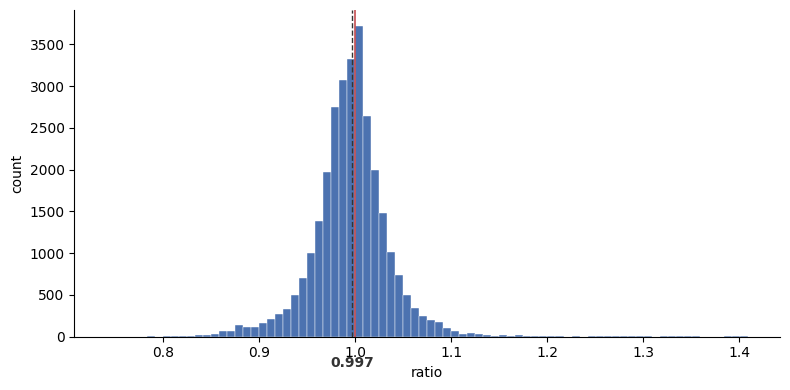

In [117]:
#VIBECODED
import matplotlib.pyplot as plt


def plot_ratio_hist(flat: torch.Tensor, bins: int = 80):
    x = flat.detach().float().cpu().numpy()
    x = x[np.isfinite(x)]
    mean = x.mean()
    fig, ax = plt.subplots(figsize=(8, 4))
    ax.hist(x, bins=bins, color="#4c72b0", edgecolor="white", linewidth=0.3)
    ax.axvline(1.0, color="#c44e52", linewidth=1.2)
    ax.axvline(mean, color="#333333", linewidth=1.0, linestyle="--")
    # mean value down on the x-axis, next to the tick labels
    ax.text(mean, -0.06, f"{mean:.3f}", ha="center", va="top",
            color="#333333", fontweight="bold", transform=ax.get_xaxis_transform())
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.set_xlabel("ratio")
    ax.set_ylabel("count")
    plt.tight_layout()
    plt.show()


plot_ratio_hist(full_position_ratios)


Seems like not that much change,lets see how no bos is

In [113]:
full_position_no_bos_ratio_attention = torch.cat([(exp_info.full_sentence_no_bos_relevant_norms[0].post_attention_norms/exp_info.full_sentence_no_bos_relevant_norms[1].post_attention_norms).flatten() for exp_info in position_norm_expirment_info])
full_position_no_bos_ratio_mlp = torch.cat([(exp_info.full_sentence_no_bos_relevant_norms[0].post_mlp_norms/exp_info.full_sentence_no_bos_relevant_norms[1].post_mlp_norms).flatten() for exp_info in position_norm_expirment_info])
full_position_no_bos_ratios = torch.cat([full_position_no_bos_ratio_attention,full_position_no_bos_ratio_mlp])



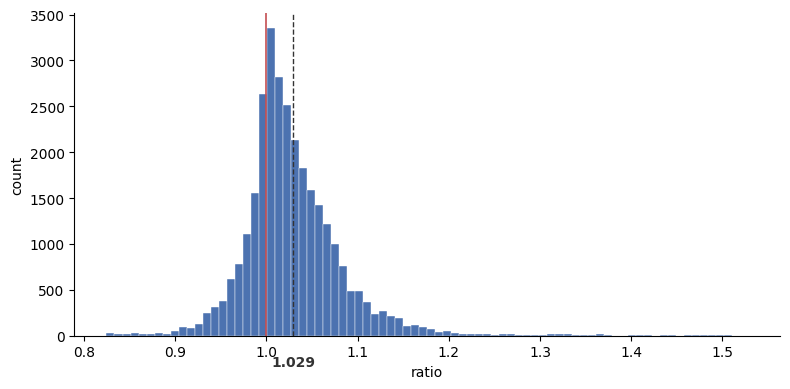

In [118]:
plot_ratio_hist(full_position_no_bos_ratios)

No BOS mean norms ratio is still very close to 1, not enoguh change to be sagnificant

plot_ratio_hist(full_position_ratios)


### Conclusion 
The remixing (a) perspective is the most accurate, and the one that it will be used   
contribution_celeb/full_position : contribution_fake/full_position -> relative proprtions of position 